In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
### System Import 
import sys
import os


In [4]:
from pathlib import Path

# Current path (where your script is located)
current_path = Path().resolve()

# Move up until reaching the repository root
repo_root = current_path.parents[3]  # go up 3 levels from utils → order_book → economy → classes → FTZ_model_2.0

# Change working directory
import os
os.chdir(repo_root)


In [5]:

import networkx as nx

from typing import List, Tuple, Union

from classes.economy.production_process.production_process import ProductionProcess

from classes.economy.order_book.utils.price_markup_generator import PriceMarkupGenerator

from classes.economy.production_process.search_space import SearchSpace

import matplotlib.pyplot as plt

In [6]:
list_1 = [ 
  ("A", "B"),
  ("B", "C"),
  ("B", "D"),
  ("B", "E"),
  ("C", "E"),
  ("D", "E"),
  ("E", "F"),
]

list_2 = [
  ("A", "D"),
  ("B", "D"),
  ("B", "E"),
  ("C", "E"),
  ("D", "F"),
  ("E", "F")
]

list_3 =  [
   
    ("A","B"), ("B","C"), ("C","D"), ("D","E"), ("E","F"),
    ("F","G"), ("G","H"), ("H","I"), ("I","J"), ("J","K"),
    ("K","L"), ("L","M"), ("M","N"), ("N","O"),
    
    ("A","O"), ("B","O"), ("C","O"), ("D","O"), ("E","O"),
    ("F","O"), ("G","O"), ("H","O"), ("I","O"), ("J","O"),
    ("K","O"), ("L","O"), ("M","O")]

list_4 = [('A','B'),('B','C'),('D','B'),('H','B')]

list_5 =[ ("A","B"), ("B","C"), ("C","D"),
  ("D","E"), ("E","F"), ("F","G"),
  ("G","H"), ("H","I"), ("I","J"),
  ("J","K"), ("K","L"), ("L","M"),
  ("M","N"), ("N","O")]

In [7]:
list = list_5

In [8]:
price_gen = PriceMarkupGenerator(list)

search_space = SearchSpace(list)


digraph = price_gen.prod_process.get_graph().get_production_graph()

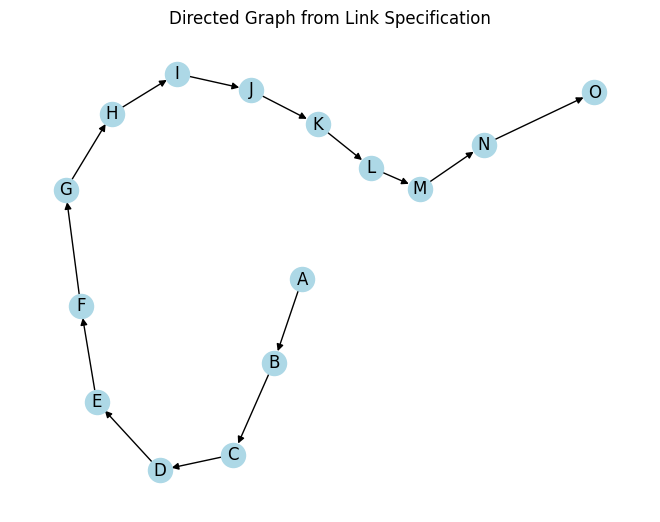

In [9]:
nx.draw(digraph, with_labels=True, node_color='lightblue', arrows=True)
plt.title("Directed Graph from Link Specification")
plt.show()


In [10]:
price_gen.get_good_topo_indices()

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14}

In [11]:
price_gen.prod_process.get_goods_classification()

{'A': 'primary',
 'B': 'intermediate',
 'C': 'intermediate',
 'D': 'intermediate',
 'E': 'intermediate',
 'F': 'intermediate',
 'G': 'intermediate',
 'H': 'intermediate',
 'I': 'intermediate',
 'J': 'intermediate',
 'K': 'intermediate',
 'L': 'intermediate',
 'M': 'intermediate',
 'N': 'intermediate',
 'O': 'final'}

In [12]:
base = 100
m1 = 0.1
m2 = 0.1
m3 = 0.02
n_agents = 3

for good, price in price_gen.generate_all_price_tensors(base,m1,m2,m3,n_agents).items():

    print('-----------------------------',{good},'---------------------------------')

    print(price)

----------------------------- {'A'} ---------------------------------
[[100 100 100]
 [100 100 100]
 [100 100 100]]
----------------------------- {'B'} ---------------------------------
[[110 110 110]
 [110 110 110]
 [110 110 110]]
----------------------------- {'C'} ---------------------------------
[[121 121 121]
 [121 121 121]
 [121 121 121]]
----------------------------- {'D'} ---------------------------------
[[133 133 133]
 [133 133 133]
 [133 133 133]]
----------------------------- {'E'} ---------------------------------
[[146 146 146]
 [146 146 146]
 [146 146 146]]
----------------------------- {'F'} ---------------------------------
[[160 160 160]
 [160 160 160]
 [160 160 160]]
----------------------------- {'G'} ---------------------------------
[[176 176 176]
 [176 176 176]
 [176 176 176]]
----------------------------- {'H'} ---------------------------------
[[193 193 193]
 [193 193 193]
 [193 193 193]]
----------------------------- {'I'} ---------------------------------
[[

In [13]:

perturbations = price_gen.generate_perturbations(seed=42 , sigma = 0.7 , ignored_indices= [0])

for good, price in price_gen.perturbed_prices.items():

    print('-----------------------------',{good},'---------------------------------')

    print(price)

price_gen.perturbed_prices

----------------------------- {'A'} ---------------------------------
[[100 100 100]
 [100 100 142]
 [100  91 100]]
----------------------------- {'B'} ---------------------------------
[[110 110 110]
 [110 110 174]
 [110 320 110]]
----------------------------- {'C'} ---------------------------------
[[121 121 121]
 [121 121 103]
 [121 103 121]]
----------------------------- {'D'} ---------------------------------
[[133 133 133]
 [133 133 402]
 [133 228 133]]
----------------------------- {'E'} ---------------------------------
[[146 146 146]
 [146 146 106]
 [146 214 146]]
----------------------------- {'F'} ---------------------------------
[[160 160 160]
 [160 160 116]
 [160 116 160]]
----------------------------- {'G'} ---------------------------------
[[176 176 176]
 [176 176 209]
 [176  47 176]]
----------------------------- {'H'} ---------------------------------
[[193 193 193]
 [193 193  58]
 [193 131 193]]
----------------------------- {'I'} ---------------------------------
[[

{'A': array([[100, 100, 100],
        [100, 100, 142],
        [100,  91, 100]]),
 'B': array([[110, 110, 110],
        [110, 110, 174],
        [110, 320, 110]]),
 'C': array([[121, 121, 121],
        [121, 121, 103],
        [121, 103, 121]]),
 'D': array([[133, 133, 133],
        [133, 133, 402],
        [133, 228, 133]]),
 'E': array([[146, 146, 146],
        [146, 146, 106],
        [146, 214, 146]]),
 'F': array([[160, 160, 160],
        [160, 160, 116],
        [160, 116, 160]]),
 'G': array([[176, 176, 176],
        [176, 176, 209],
        [176,  47, 176]]),
 'H': array([[193, 193, 193],
        [193, 193,  58],
        [193, 131, 193]]),
 'I': array([[212, 212, 212],
        [212, 212, 105],
        [212, 265, 212]]),
 'J': array([[233, 233, 233],
        [233, 233, 124],
        [233,  87, 233]]),
 'K': array([[256, 256, 256],
        [256, 256, 715],
        [256, 219, 256]]),
 'L': array([[281, 281, 281],
        [281, 281, 295],
        [281, 104, 281]]),
 'M': array([[30

In [14]:
a = search_space.calculate_search_space(fix_last_gene=True , verbosity=True)

a

n = 16, k = 1, primary_combinations = 2


{'search_space': 65536, 'reduced_search_space': 32768}

In [15]:
search_space.prod_process.get_goods_classification()

{'A': 'primary',
 'B': 'intermediate',
 'C': 'intermediate',
 'D': 'intermediate',
 'E': 'intermediate',
 'F': 'intermediate',
 'G': 'intermediate',
 'H': 'intermediate',
 'I': 'intermediate',
 'J': 'intermediate',
 'K': 'intermediate',
 'L': 'intermediate',
 'M': 'intermediate',
 'N': 'intermediate',
 'O': 'final'}

In [16]:
primary_goods = [g for g, cls in search_space.prod_process.get_goods_classification().items() if cls == "primary_good"]

print(primary_goods)

[]


In [17]:
search_space.prod_process.get_required_quantities()

{'A': 1,
 'B': 1,
 'C': 1,
 'D': 1,
 'E': 1,
 'F': 1,
 'G': 1,
 'H': 1,
 'I': 1,
 'J': 1,
 'K': 1,
 'L': 1,
 'M': 1,
 'N': 1,
 'O': 1}